In [1]:
snnapdatapath = "/media/udickman/uri-external-drive/SNNAP_data/fig8"
excelpath = "../Excel_files"
figpath = "../figs"
fig_prefix = "Dickman_etal_Results"
excelfile = "fig8.xlsx"

# Run this cell, then comment out the lines below and restart the kernel.
# import os
# !yes | neuronpyxl -f gen_mods --file {os.path.join(excelpath,excelfile)}

In [2]:
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt
import sys
sys.path.append("../")
from neuronpyxl import network
import numpy as np
import math
import os

snnap_data = pd.read_csv(os.path.join(snnapdatapath,"synapse_vsyn2.smu.out"), sep="\t").dropna(axis=1)
snnap_data.columns = ["t", "VA", "", "VB"]

In [3]:
nb = network.NetworkBuilder(params_file=os.path.join(excelpath, excelfile), sim_name="main",
                            noise=None,dt=0.005,integrator=2,atol=1e-5,eq_time=0,simdur=6000,seed=False)

nb.run(voltage_only=True)

tvec = np.array(snnap_data["t"])*1000
A = nb.get_interpolated_cell_data("A",tvec)
B = nb.get_interpolated_cell_data("B",tvec)
t = np.array(A["t"]) / 1000

Added Cell(gid=1, name=A) to the network.
Added Cell(gid=2, name=B) to the network.
Loading simulation parameters...
Running simulation...


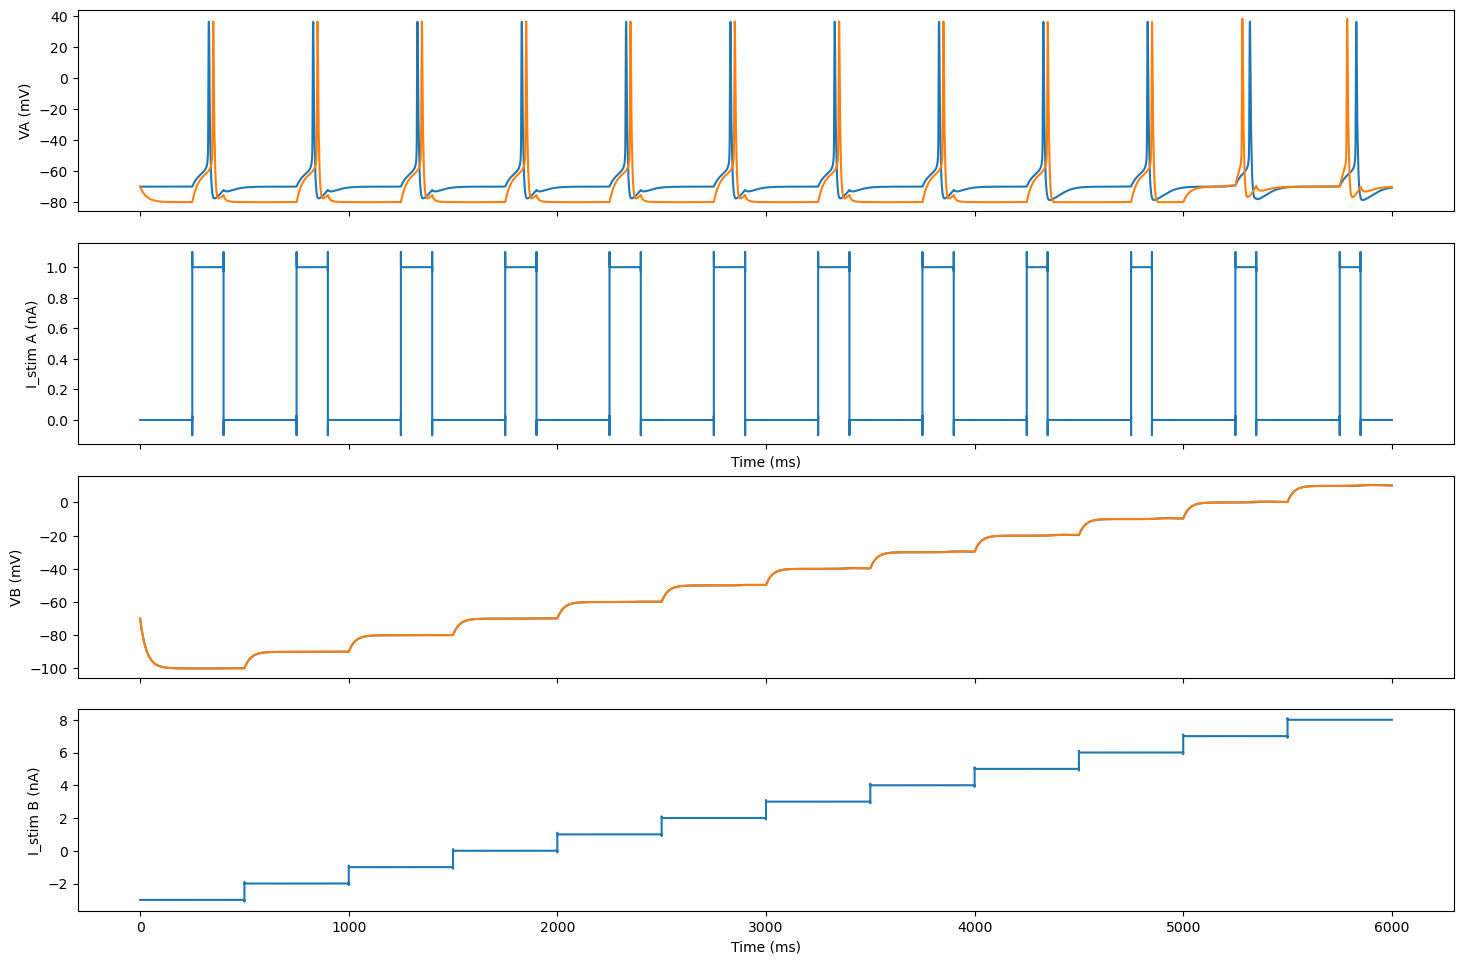

In [4]:
fig, ax = plt.subplots(4, 1, figsize=(15,10), sharex=True)
ax[0].plot(A["t"], A["V"])
ax[0].set_ylabel("VA (mV)")
ax[0].plot(snnap_data["t"]*1000, snnap_data["VA"])

ax[1].plot(A["t"], A["I_applied_0.5"])
ax[1].set_ylabel("I_stim A (nA)")
ax[1].set_xlabel("Time (ms)")

ax[2].plot(B["t"], B["V"])
ax[2].plot(snnap_data["t"]*1000, snnap_data["VB"])
ax[2].set_ylabel("VB (mV)")

ax[3].plot(B["t"], B["I_applied_0.5"])
ax[3].set_ylabel("I_stim B (nA)")
ax[3].set_xlabel("Time (ms)")
plt.tight_layout(pad=2.0, w_pad=0.5, h_pad=0.5)

In [5]:
def remove_axes(ax,remove_x=True,remove_y=False):
    # For aesthetics
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if remove_x:
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
    if remove_y:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        
def plot_vertical_scalebar(ax,scalebar_length=20,bar_width=0.25,offset=0,yoffset=10):
    from matplotlib.patches import Rectangle
    # Get axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Coordinates for bottom-right corner
    x_start = xlim[1] - offset - bar_width
    y_start = ylim[0] + offset + yoffset

    scalebar = Rectangle((x_start, y_start), width=bar_width, height=scalebar_length,
                        color='black', linewidth=0, zorder=10)

    ax.add_patch(scalebar)

    # Optional: Add text label
    ax.text(x_start-1, y_start + scalebar_length / 2, f'{scalebar_length} mV',
            va='center', ha='right', color='black', fontsize=16)

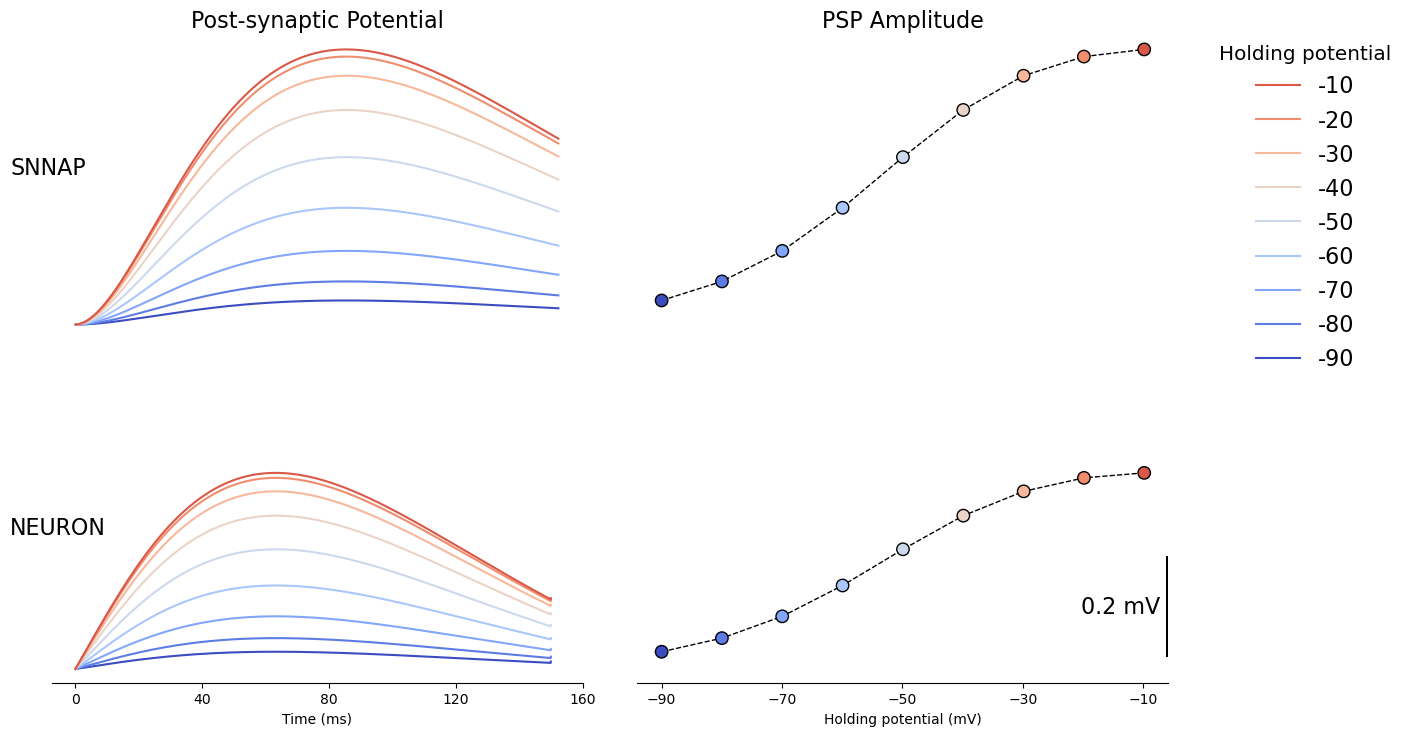

In [10]:
times = np.array([(850, 1000), (1350, 1500), (1850, 2000), (2350, 2500), (2850, 3000), (3350, 3500), (3850, 4000), (4350, 4500), (4850, 5000)])
dt = 0.005
# Convert times to indices directly
indices = (times / dt).astype(int)

from matplotlib import colormaps
cmap = colormaps['coolwarm']
colors = [cmap(i/9) for i in range(9)]  # 10 colors from the colormap

amps_snnap = []
Vs_snnap = []

fig, axs = plt.subplots(2, 2, figsize=(12, 8),sharey=True)

# Plot in a single loop without building the ranges list
for i,(start, end) in enumerate(indices):
    x = np.asarray(snnap_data["t"][start:end-15]*1000 - snnap_data["t"][start]*1000)
    y = np.asarray(snnap_data["VB"][start:end-15] - snnap_data["VB"][start])
    Vs_snnap.append(snnap_data["VB"][start])
    amps_snnap.append(max(y))
    axs[0, 0].plot(x, y, label=f'{math.floor(snnap_data["VB"][end])}',color=colors[i])
# axs[0, 0].set_ylabel("Voltage (mV)")
    
# axs[0,1].plot(Vs_snnap, amps_snnap, label="SNNAP",color="orangered")
axs[0,1].plot(Vs_snnap, amps_snnap,color="black",linewidth=1,linestyle="dashed")
axs[0,1].scatter(Vs_snnap, amps_snnap,color=colors,marker="o",s=80,zorder=2,edgecolors="black")
# axs[0,1].set_xlabel("Holding potential (mV)")
# axs[0,1].set_ylabel("PSP Amplitude (mV)")

amps_nrn = []
Vs_nrn = []

# Plot in a single loop without building the ranges list
for i,(start, end) in enumerate(indices):
    x = np.asarray(B["t"][start:end] - B["t"][start])
    y = np.asarray(B["V"][start:end] - B["V"][start])
    Vs_nrn.append(B["V"][start])
    amps_nrn.append(max(y))
    axs[1,0].plot(x,y, label=f'{math.floor(B["V"][end])}',color=colors[i])
# axs[1,0].set_ylabel("Voltage (mV)")
axs[1,0].set_yticks([0,0.25,0.5])
axs[0,0].set_yticks([0,0.25,0.5])

axs[1,1].plot(Vs_nrn, amps_nrn,color="black",linewidth=1,linestyle="dashed")
axs[1,1].scatter(Vs_nrn, amps_nrn,color=colors,marker="o",s=80,zorder=2,edgecolors="black")
axs[1,1].set_xlabel("Holding potential (mV)")
axs[1,1].set_xticks([-90,-70,-50,-30,-10])
axs[1,0].set_xlabel("Time (ms)")
axs[1,0].set_xticks([0,40,80,120,160])
# axs[1,1].set_ylabel("PSP Amplitude (mV)")

remove_axes(axs[0,0],remove_x=True,remove_y=True)
remove_axes(axs[1,0],remove_x=False,remove_y=True)
remove_axes(axs[0,1],remove_x=True,remove_y=True)
remove_axes(axs[1,1],remove_x=False,remove_y=True)

fig.text(0, 0.75, "SNNAP", fontsize=16, va='center', ha='left')
fig.text(0, 0.3, "NEURON", fontsize=16, va='center', ha='left')

axs[0,0].set_title("Post-synaptic Potential",fontsize=16)
axs[0,1].set_title("PSP Amplitude",fontsize=16)
# axs[0, 0].legend(title='Holding potential',fontsize=12,bbox_to_anchor=(-0.5,0.5),loc="center left",title_fontsize='medium')
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles[::-1], labels[::-1],
    title="Holding potential",
    title_fontsize='x-large',
    fontsize=16,
    loc="center left",
    bbox_to_anchor=(1, 0.7),  # tweak these values for fine placement
    frameon=False,
    borderaxespad=0,
    ncol=1,
    bbox_transform=fig.transFigure
)

plot_vertical_scalebar(axs[1,1],scalebar_length=0.2,bar_width=0.4,yoffset=0.05)
fig.tight_layout(pad=3.0)
fig.align_ylabels()
# fig.suptitle("Response of B to Single Spikes in A",fontsize=20)
# plt.tight_layout(pad=2.0, w_pad=0.5, h_pad=0.5)
fig.savefig(os.path.join(figpath,f"{fig_prefix}_psp.jpg"), dpi=300, bbox_inches='tight')